# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

!pip install numpy pandas seaborn scikit-learn tqdm

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


In [3]:
## Overview

print("Shape of dataset: ", df.shape)
print("\nColumn names:\n", df.columns)
print("\nData types and non-null counts: ")
print(df.info())
print("\nSummary statistics: ")
print(df.describe())

Shape of dataset:  (77613, 55)

Column names:
 Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
     


Missing values per column: 
buildingclasstypeid             77598
finishedsquarefeet13            77571
basementsqft                    77563
storytypeid                     77563
yardbuildingsqft26              77543
fireplaceflag                   77441
architecturalstyletypeid        77406
typeconstructiontypeid          77390
finishedsquarefeet6             77227
pooltypeid10                    77148
decktypeid                      76999
poolsizesum                     76744
pooltypeid2                     76539
hashottuborspa                  76074
yardbuildingsqft17              75220
taxdelinquencyyear              74713
taxdelinquencyflag              74713
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedfloor1squarefeet        71576
fireplacecnt                    69324
threequarterbathnbr             67507
pooltypeid7                     62534
poolcnt                         61439
numberofstories                 60014
airconditioningtypeid

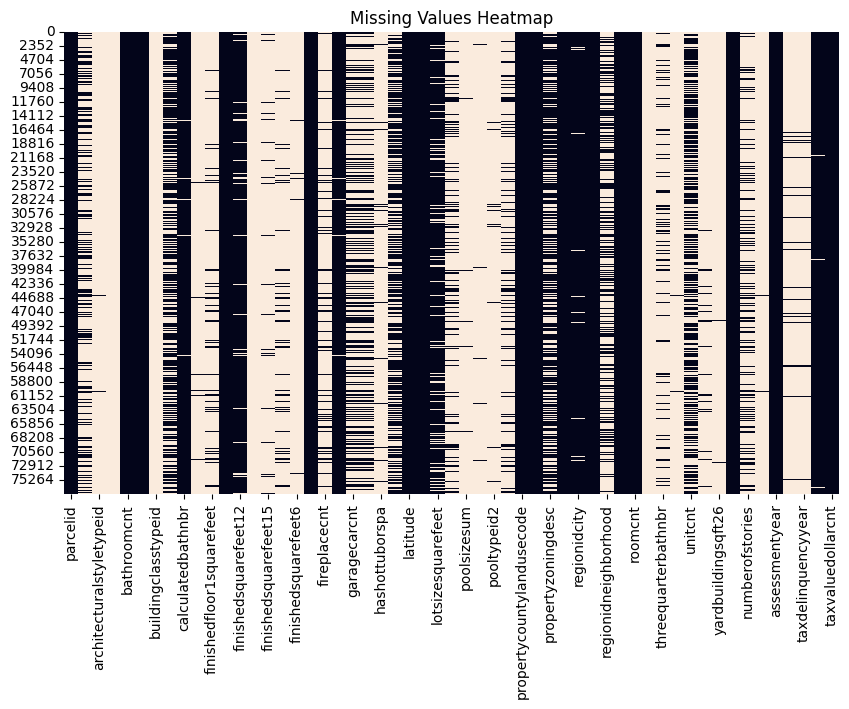

In [4]:
## Missing values

print("\nMissing values per column: ")
print(df.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [5]:
## Duplicate Rows

duplicates = df.duplicated().sum()
print("\nNumber of duplicated rows: ", duplicates)


Number of duplicated rows:  199


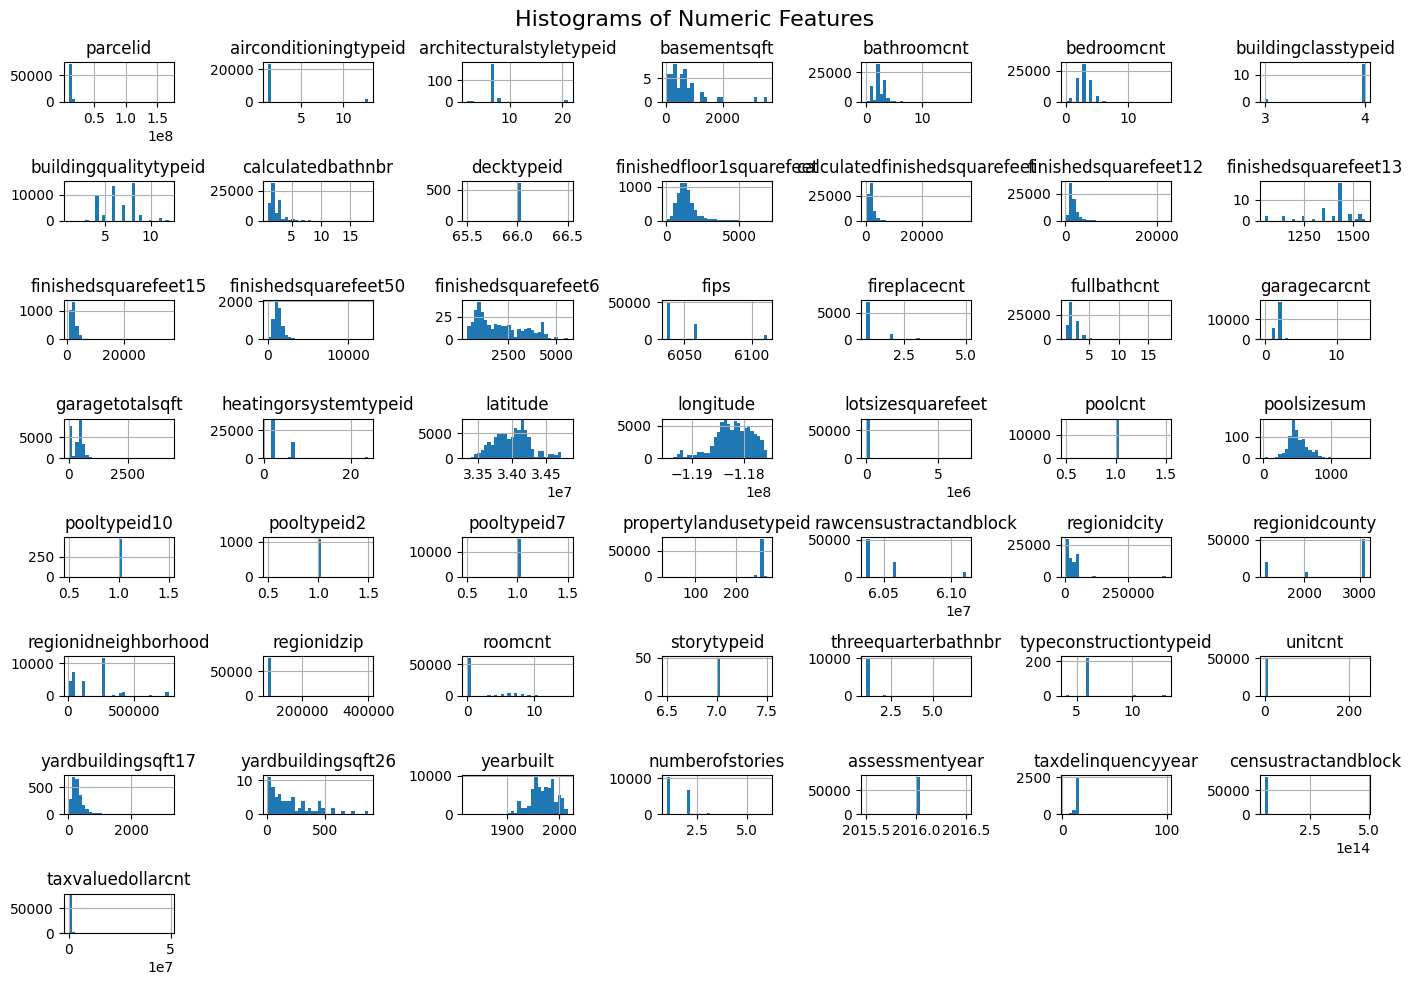

In [6]:
## Univariate analysis

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

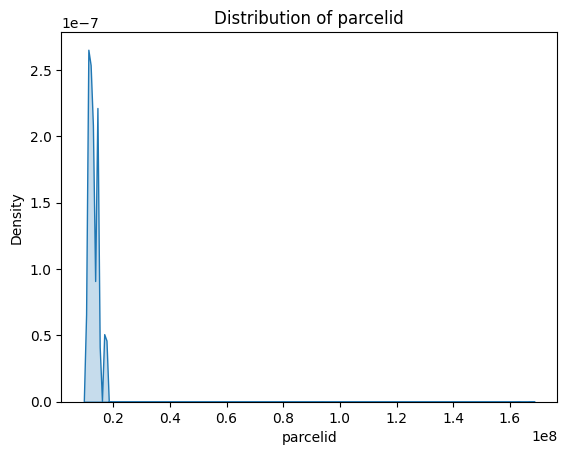

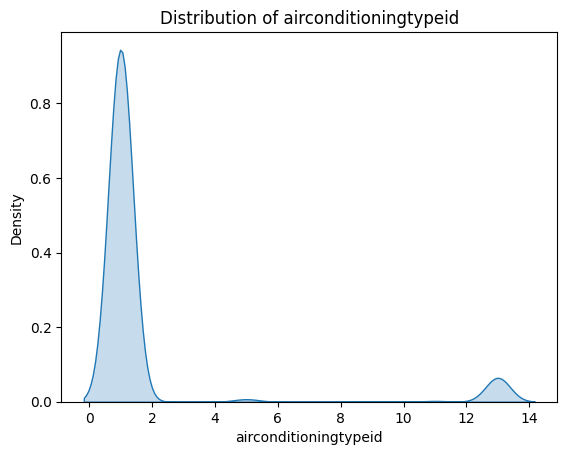

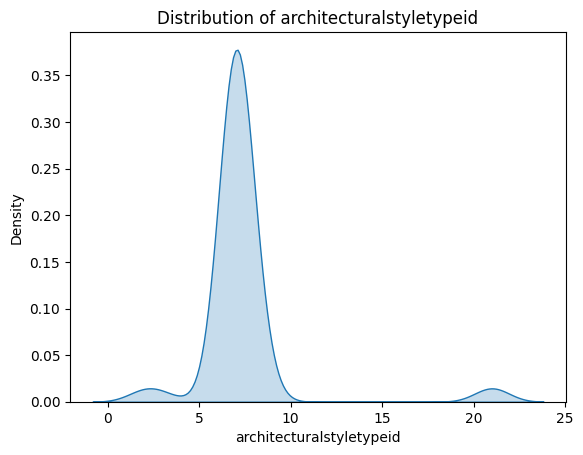

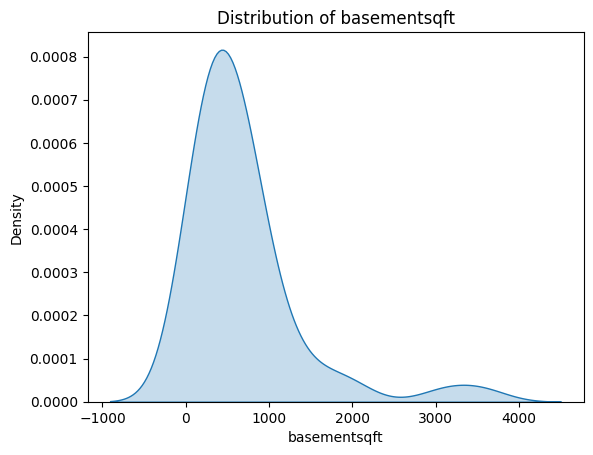

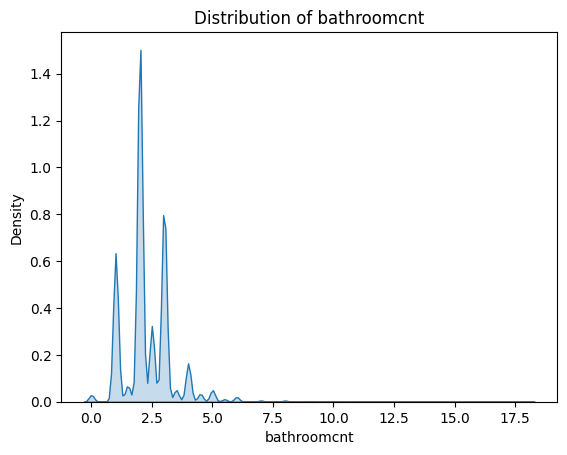

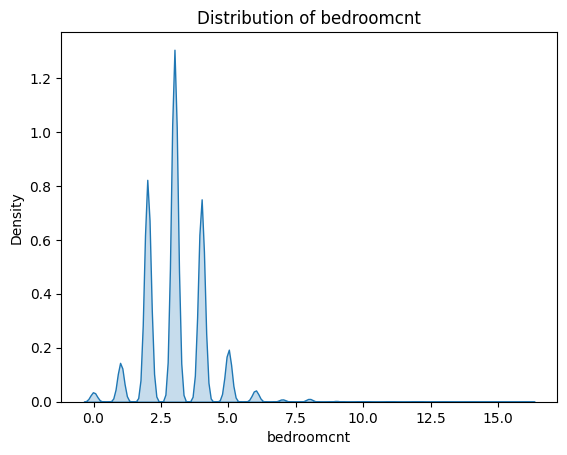

In [7]:
## KDE plots

for col in numeric_cols[:6]:
    plt.figure()
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

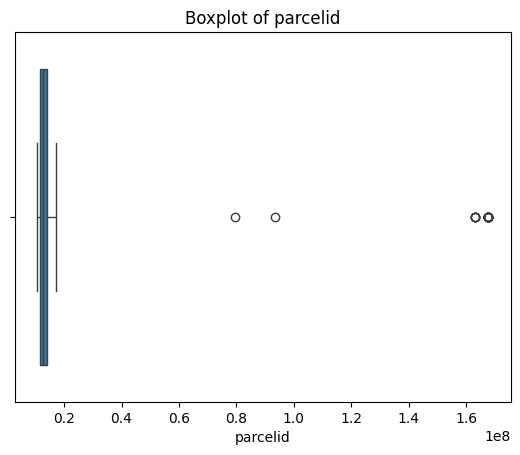

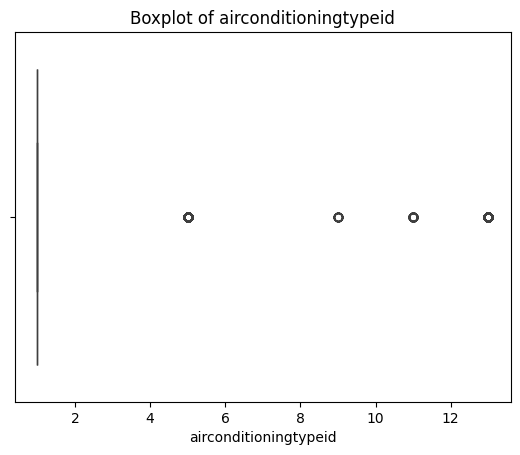

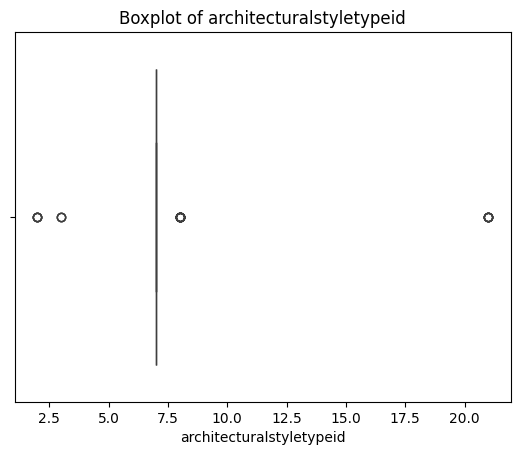

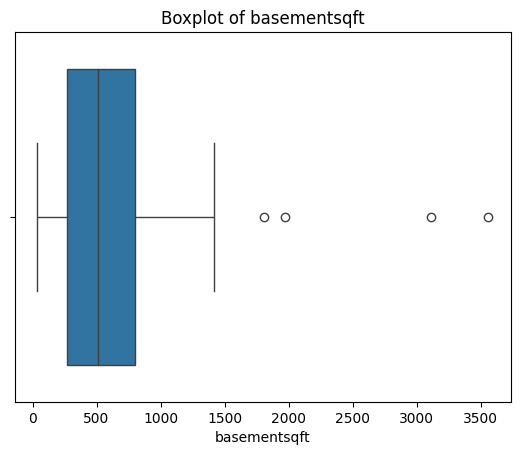

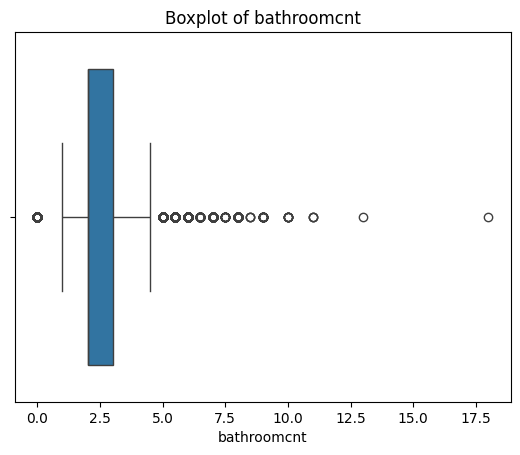

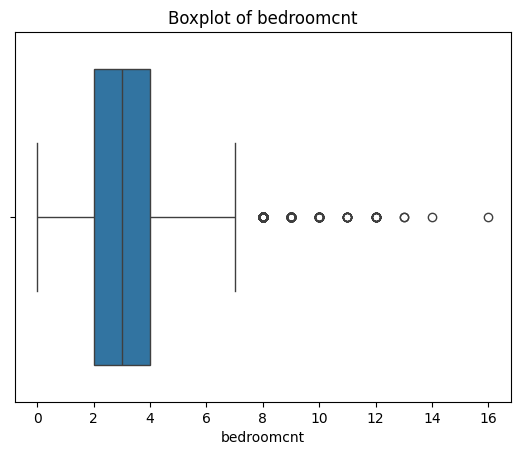

In [8]:
## Outlier Detection

for col in numeric_cols[:6]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

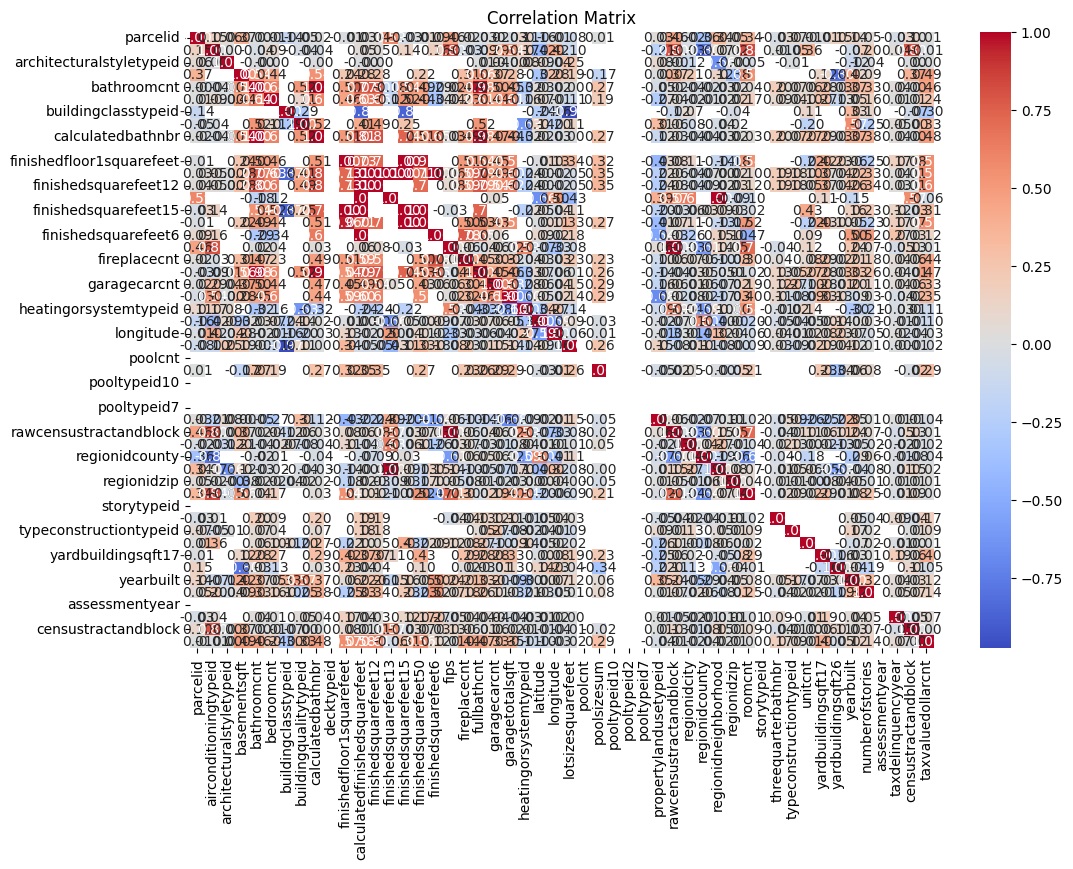

In [9]:
## Correlation analysis

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

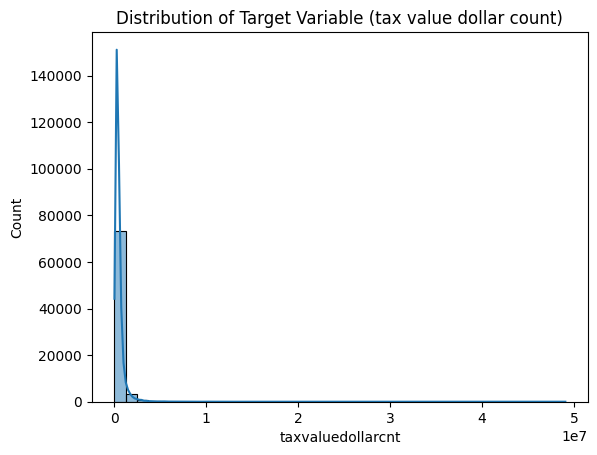

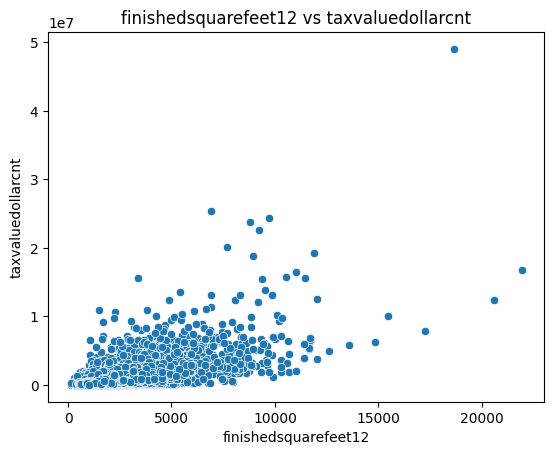

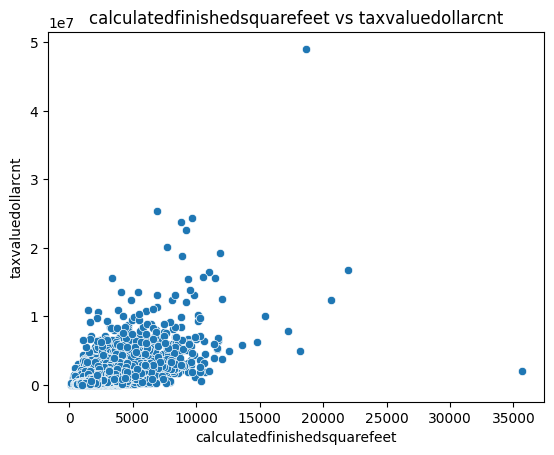

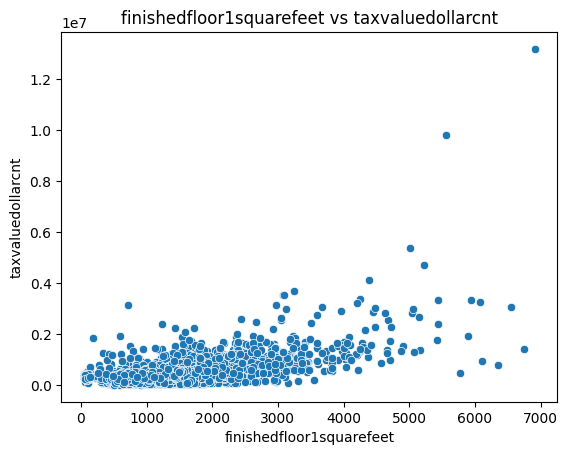

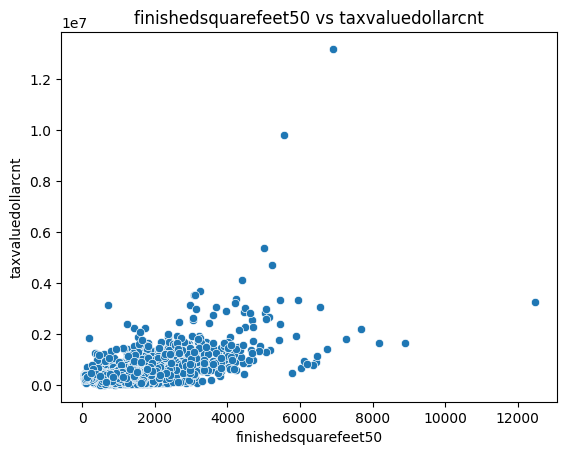

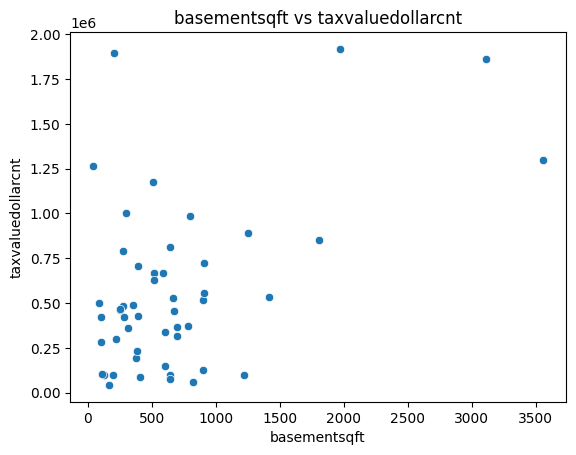

In [10]:
## target variable (price)

target = 'taxvaluedollarcnt'

if target in df.columns:
    plt.figure()
    sns.histplot(df[target], bins=40, kde=True)
    plt.title("Distribution of Target Variable (tax value dollar count)")
    plt.show()

    top_features = corr[target].abs().sort_values(ascending=False)[1:6].index

    for col in top_features:
        plt.figure()
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

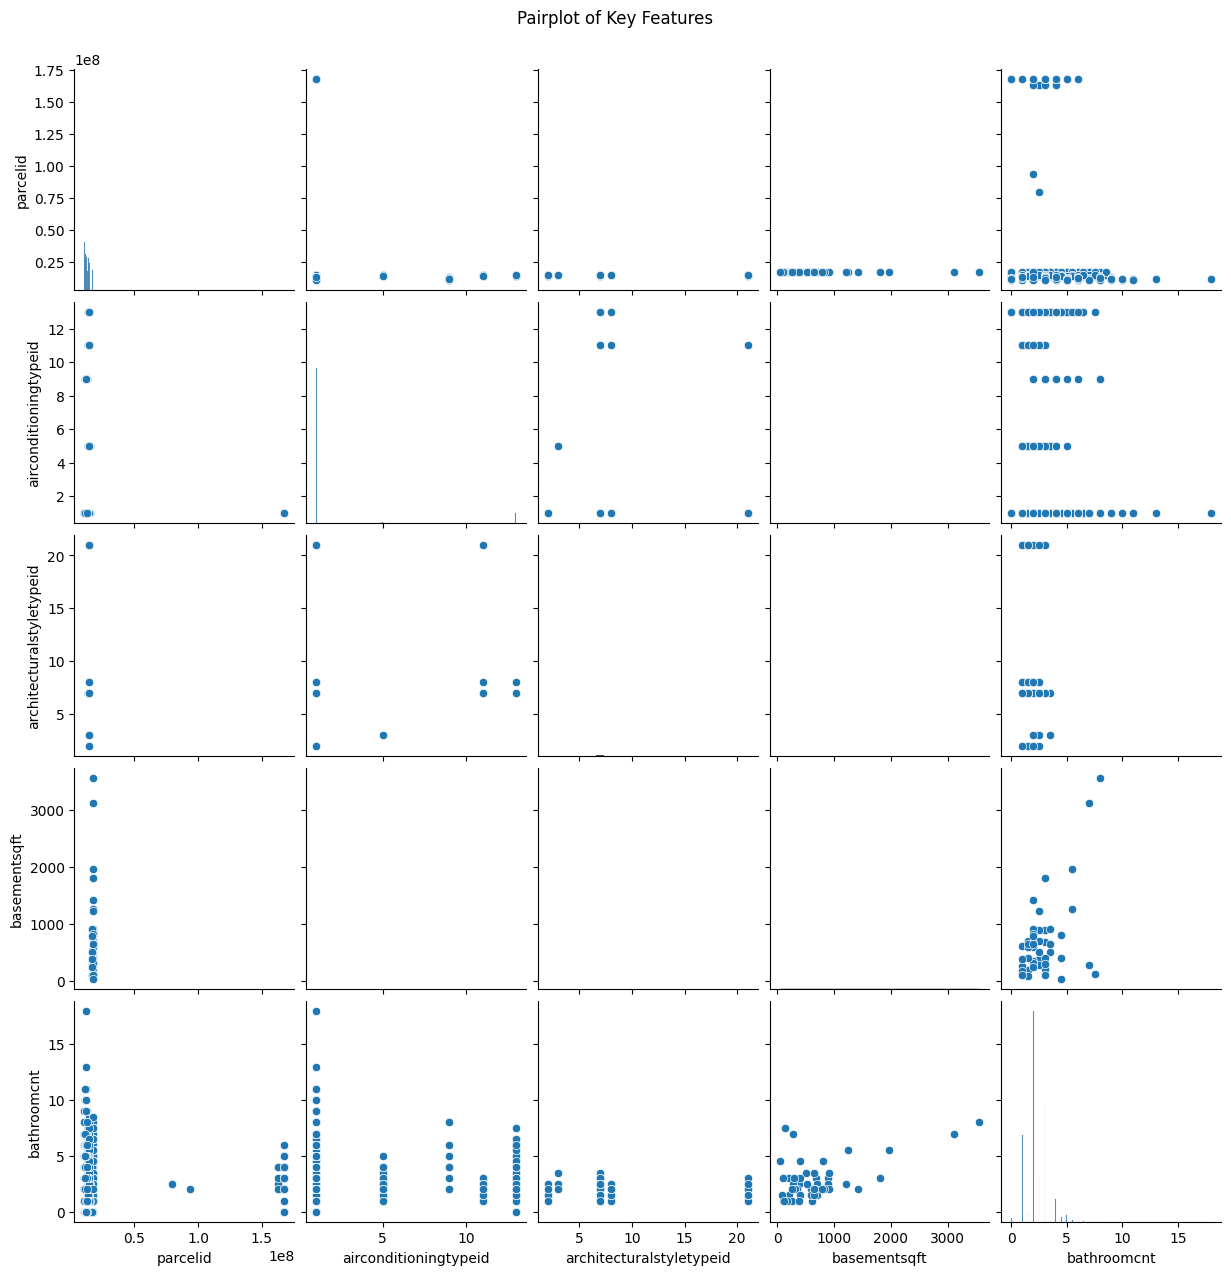

In [11]:
## key relationship pairplots

sns.pairplot(df[numeric_cols[:5]])
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [12]:
print("First 5 rows: ")
print(df.head())

print("\nDataset info: ")
df.info()

print("\nUnique values per column: ")
print(df.nunique())

summary = []

for col in df.columns:
    dtype = df[col].dtype
    unique_vals = df[col].nunique()
    missing_pct = df[col].isnull().mean() * 100

    if pd.api.types.is_numeric_dtype(df[col]):
        col_type = "numeric (int/float)"
    elif pd.api.types.is_string_dtype(df[col]):
        col_type = "text/categorical"
    else:
        col_type = "other"

    if col.lower() in ['taxvaluedollarcnt']:
        usefulness = "Target variable (very useful)"
    elif unique_vals < 10:
        usefulness = "Categorical feature (potentially useful)"
    else:
        usefulness = "Likely useful feature"

    summary.append({
        "Column": col,
        "Type": col_type,
        "Unique Values": unique_vals,
        "% Missing": round(missing_pct, 2),
        "Usefulness": usefulness
    })

summary_df = pd.DataFrame(summary)

print("\nFeature Summary: ")
print(summary_df)

First 5 rows: 
   parcelid  airconditioningtypeid  architecturalstyletypeid  basementsqft  \
0  14297519                    NaN                       NaN           NaN   
1  17052889                    NaN                       NaN           NaN   
2  14186244                    NaN                       NaN           NaN   
3  12177905                    NaN                       NaN           NaN   
4  10887214                    1.0                       NaN           NaN   

   bathroomcnt  bedroomcnt  buildingclasstypeid  buildingqualitytypeid  \
0          3.5         4.0                  NaN                    NaN   
1          1.0         2.0                  NaN                    NaN   
2          2.0         3.0                  NaN                    NaN   
3          3.0         4.0                  NaN                    8.0   
4          3.0         3.0                  NaN                    8.0   

   calculatedbathnbr  decktypeid  ...  yardbuildingsqft17  yardbuilding

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

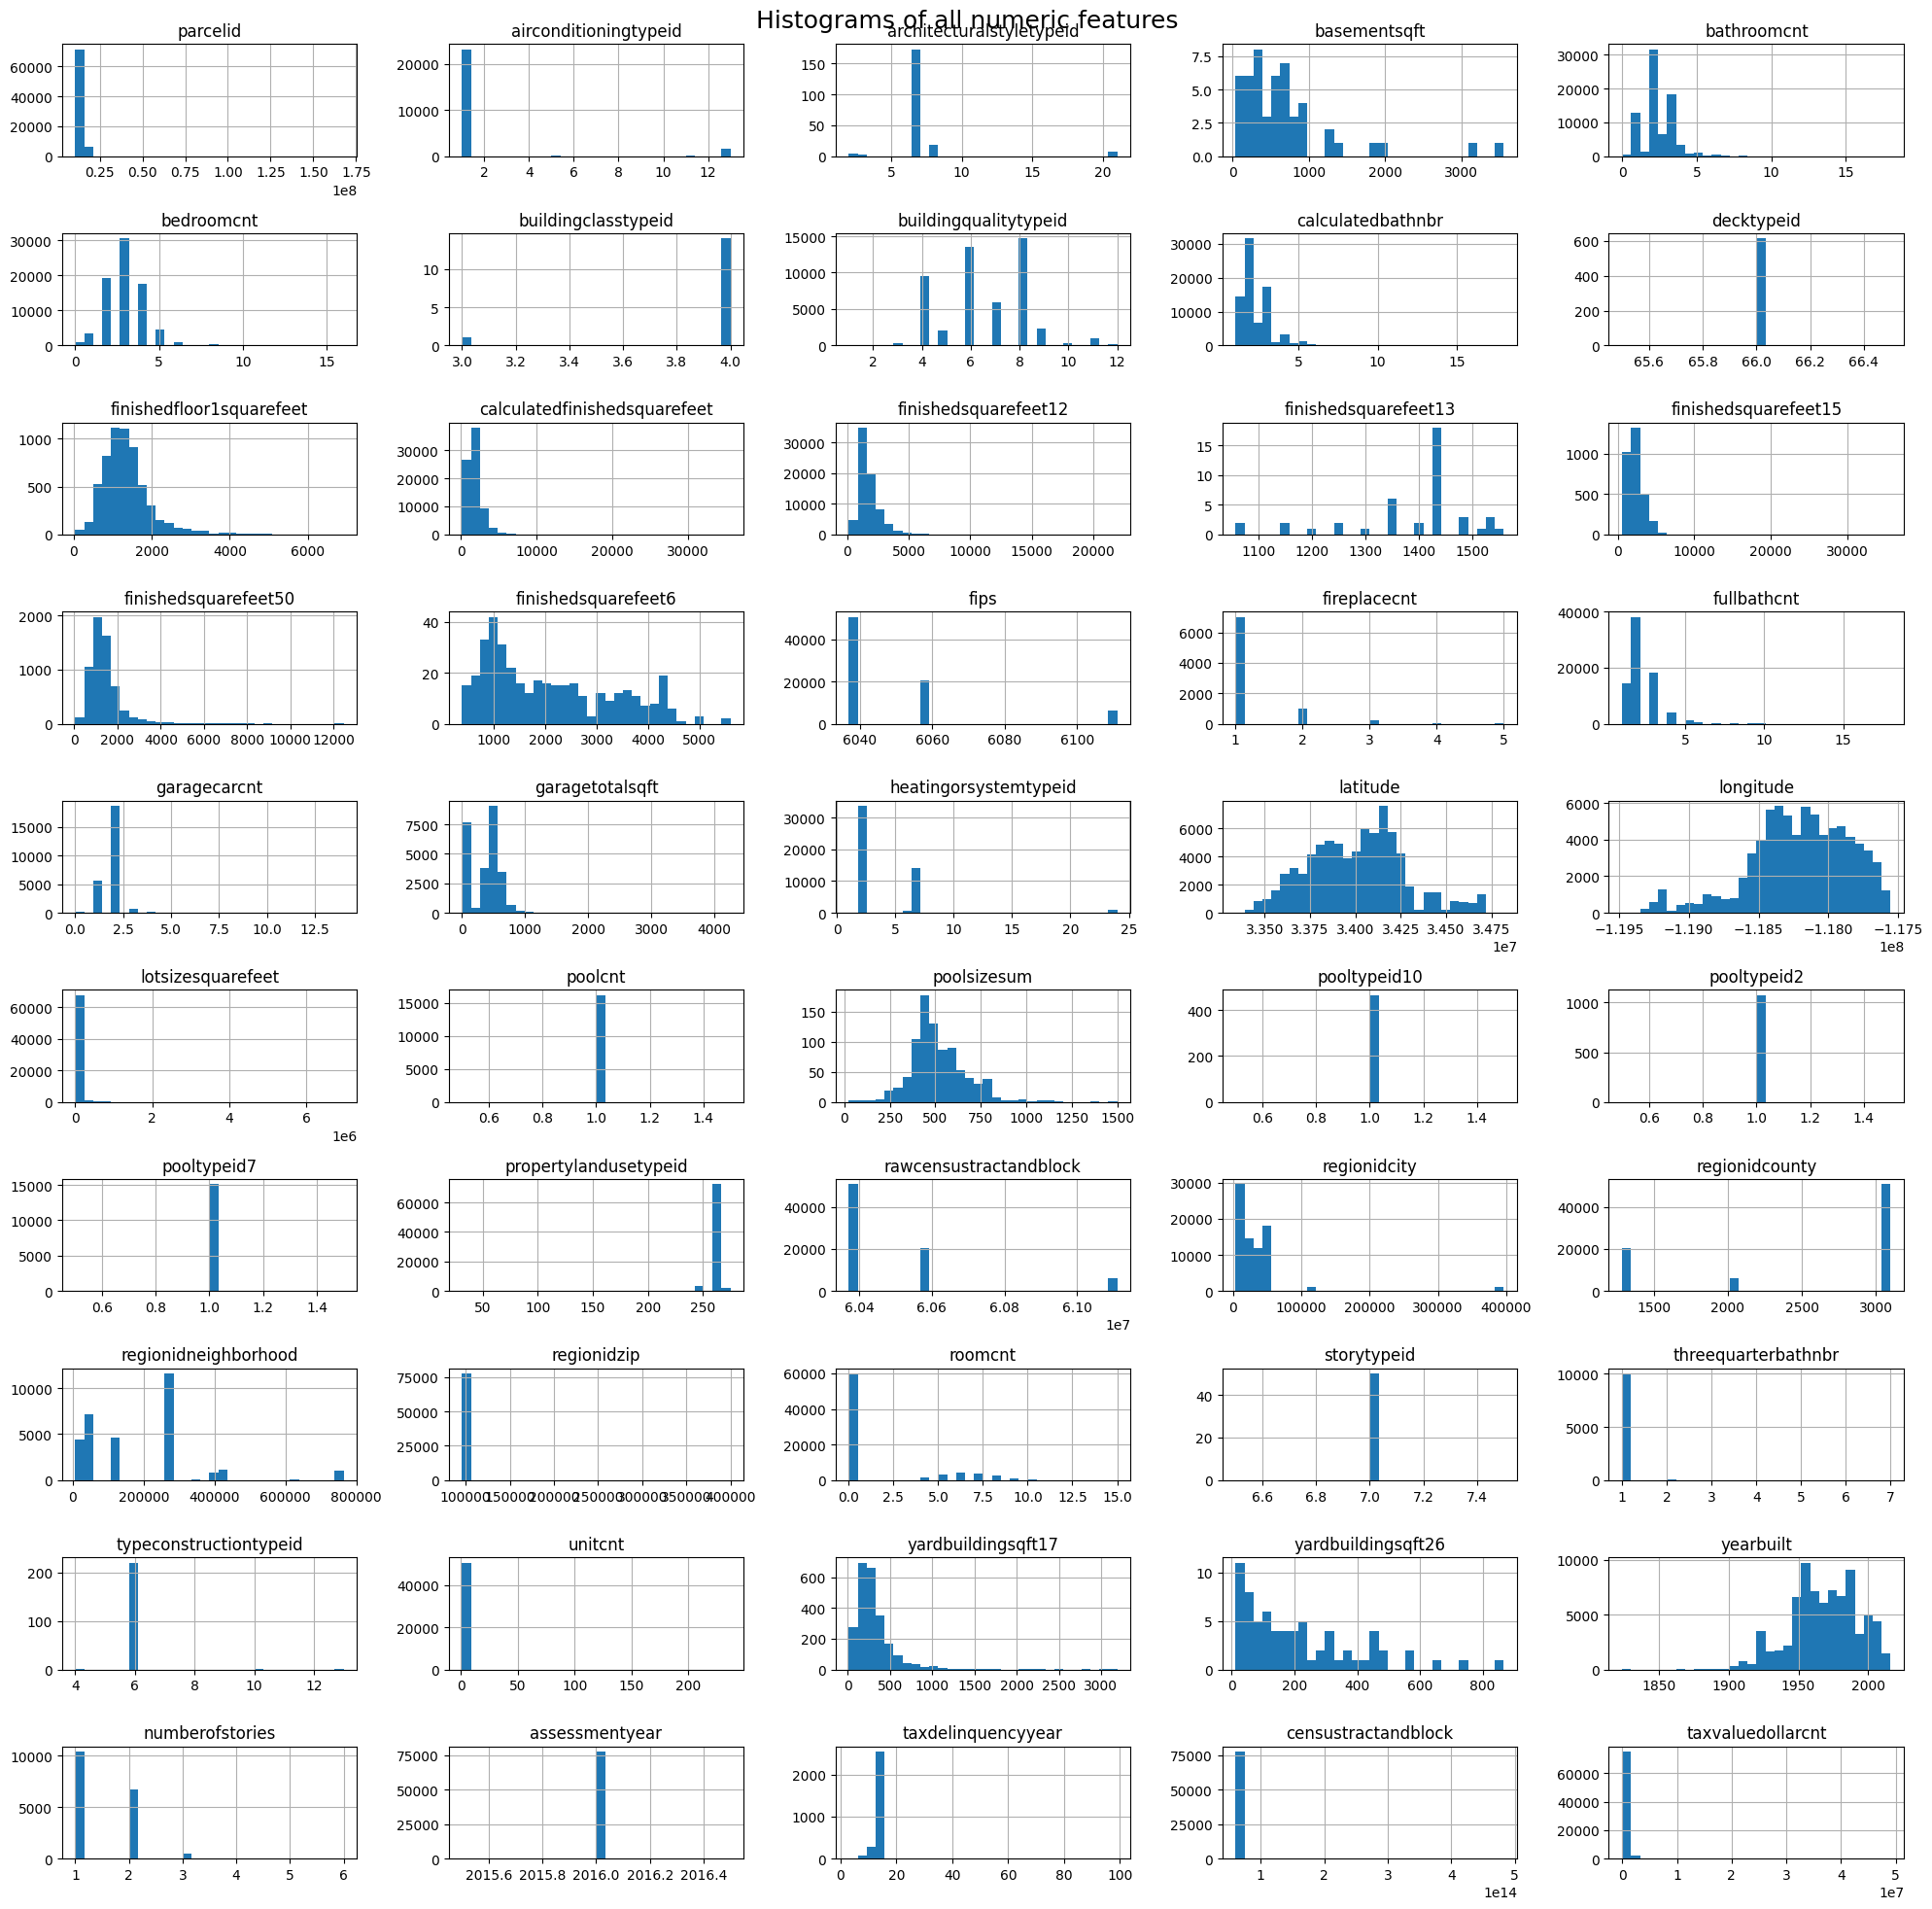

In [13]:
## histograms for all numeric features

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(20,20), bins=30, layout=(-1,5))

plt.suptitle("Histograms of all numeric features", fontsize=18)
plt.tight_layout()
plt.show()

focused analysis

target = taxvaluedollarcnt

3 features = calculatedfinishedsquarefeet, bedroomcnt, yearbuilt

all three are relevent for pricing


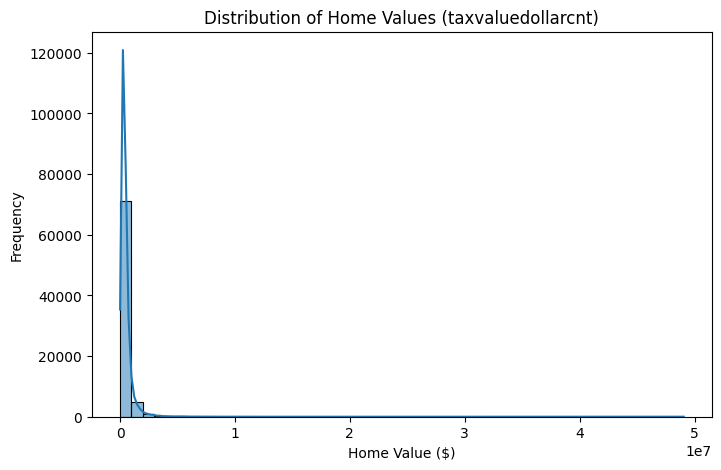

In [14]:
## distribution of target variable

plt.figure(figsize=(8,5))
sns.histplot(df['taxvaluedollarcnt'], bins=50, kde=True)

plt.title("Distribution of Home Values (taxvaluedollarcnt)")
plt.xlabel("Home Value ($)")
plt.ylabel("Frequency")
plt.show()

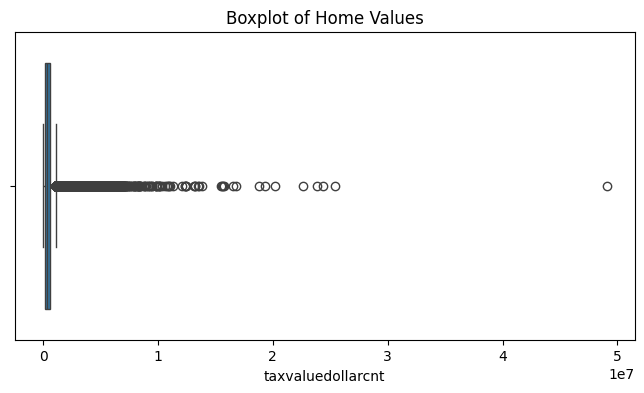

In [15]:
## boxplot for target variable

plt.figure(figsize=(8,4))
sns.boxplot(x=df['taxvaluedollarcnt'])
plt.title("Boxplot of Home Values")
plt.show()

Home values are highly right skewed with a few extremely expensive properties.

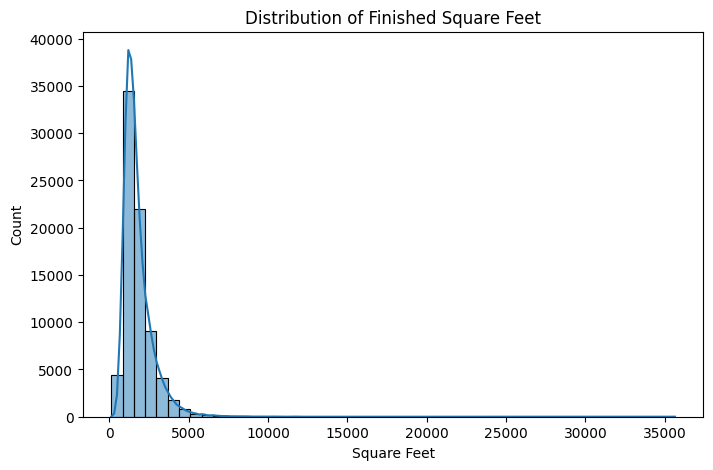

In [16]:
## distribution of square footage

plt.figure(figsize=(8,5))
sns.histplot(df['calculatedfinishedsquarefeet'], bins=50, kde=True)

plt.title("Distribution of Finished Square Feet")
plt.xlabel("Square Feet")
plt.show()

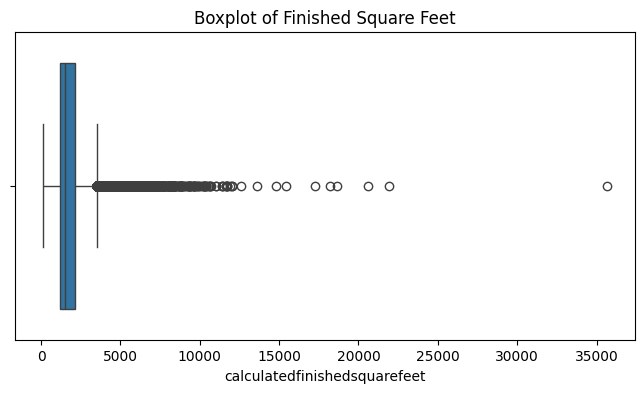

In [17]:
## boxplot of square footage

plt.figure(figsize=(8,4))
sns.boxplot(x=df['calculatedfinishedsquarefeet'])

plt.title("Boxplot of Finished Square Feet")
plt.show()

Square footage is also right skewed with some large outliers.

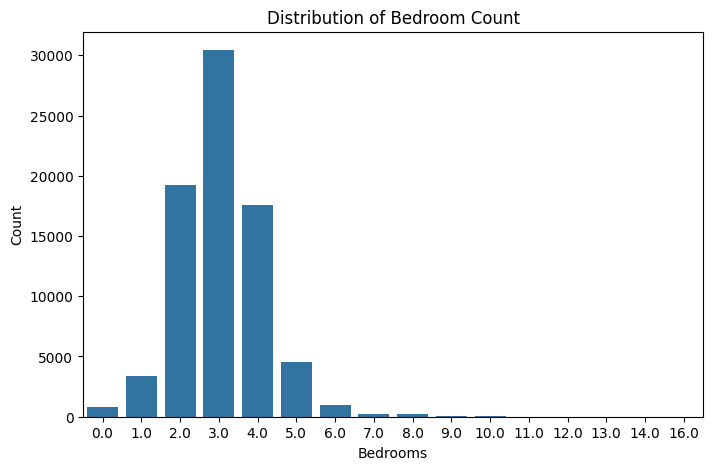

In [18]:
## bedroom count distribution

plt.figure(figsize=(8,5))
sns.countplot(x=df['bedroomcnt'])

plt.title("Distribution of Bedroom Count")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

Bedroom count is concentrated around 2-4 bedrooms.

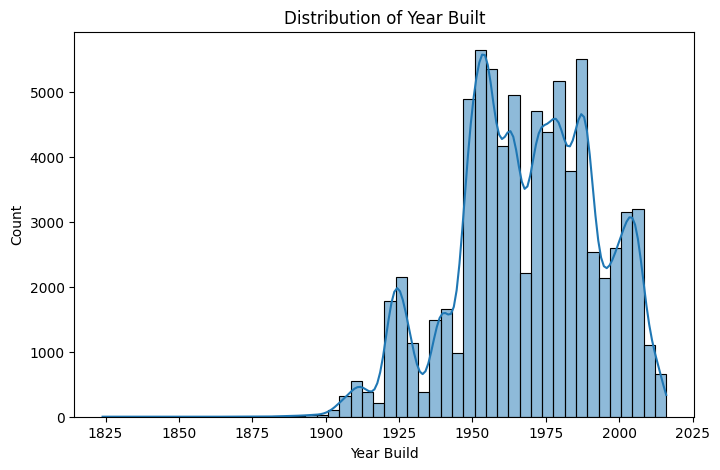

In [19]:
## year built distribution

plt.figure(figsize=(8,5))
sns.histplot(df['yearbuilt'], bins=50, kde=True)

plt.title("Distribution of Year Built")
plt.xlabel("Year Build")
plt.show()

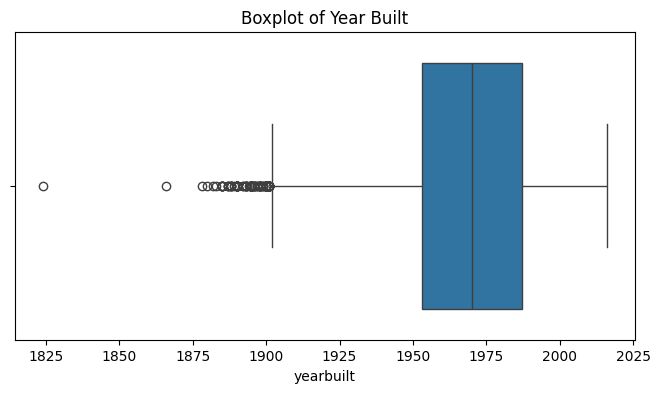

In [20]:
## year built outliers

plt.figure(figsize=(8,4))
sns.boxplot(x=df['yearbuilt'])

plt.title("Boxplot of Year Built")
plt.show()

Year built shows most homes are mid-1900s to early 2000s, but there are a few early outliers.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [21]:
def drop_unsuitable_features(input_df):
    df_stage1 = input_df.copy()

    manual_drop = [
        'parcelid'
    ]

    low_variation_cols = []

    for col in df_stage1.columns:
        non_null_vals = df_stage1[col].dropna()

        if len(non_null_vals) > 0:
            if non_null_vals.nunique() <= 1:
                low_variation_cols.append(col)

    cols_to_drop = sorted(set(manual_drop + low_variation_cols))

    df_stage2 = df_stage1.drop(columns=cols_to_drop, errors='ignore')

    return df_stage2, cols_to_drop

In [22]:
df_stage2, dropped_columns = drop_unsuitable_features(df)

print("Dropped columns: ")
print(dropped_columns)

print("\nOriginal shape: ", df.shape)
print("New shape: ", df_stage2.shape)

Dropped columns: 
['assessmentyear', 'decktypeid', 'fireplaceflag', 'hashottuborspa', 'parcelid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'taxdelinquencyflag']

Original shape:  (77613, 55)
New shape:  (77613, 44)


In [23]:
print(df_stage2.columns.tolist())

['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolsizesum', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'taxdelinquencyyear', 'censustractandblock', 'taxvaluedollarcnt']


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


In this step, I removed features that are inherently unsuitable for regression. This included identifier columns such as parcelid, which do not provide predictive information, and features with no variation like constant columns since they cannot help distinguish between observations.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [24]:
## look at missingness in a summary table

def summarize_missingness(input_df):
    df_stage2a = input_df.copy()

    missing_summary = pd.DataFrame({
        "column": df_stage2a.columns,
        "non_null_count": df_stage2a.notnull().sum().values,
        "missing_count": df_stage2a.isnull().sum().values,
        "missing_pct": (df_stage2a.isnull().mean() * 100).values,
        "unique_non_null": [df_stage2a[col].nunique(dropna=True) for col in df_stage2a.columns],
        "dtype": df_stage2a.dtypes.values
    })

    missing_summary = missing_summary.sort_values("missing_pct", ascending=False).reset_index(drop=True)
    return missing_summary

missing_summary_df = summarize_missingness(df_stage2)
print(missing_summary_df)

                          column  non_null_count  missing_count  missing_pct  \
0            buildingclasstypeid              15          77598    99.980673   
1           finishedsquarefeet13              42          77571    99.945885   
2                   basementsqft              50          77563    99.935578   
3             yardbuildingsqft26              70          77543    99.909809   
4       architecturalstyletypeid             207          77406    99.733292   
5         typeconstructiontypeid             223          77390    99.712677   
6            finishedsquarefeet6             386          77227    99.502661   
7                    poolsizesum             869          76744    98.880342   
8             yardbuildingsqft17            2393          75220    96.916754   
9             taxdelinquencyyear            2900          74713    96.263513   
10          finishedsquarefeet15            3027          74586    96.099880   
11      finishedfloor1squarefeet        

In [25]:
## look at columns with very high missingness

very_sparse_df = missing_summary_df[missing_summary_df["missing_pct"] > 85]
print(very_sparse_df[["column", "non_null_count", "missing_pct", "unique_non_null", "dtype"]])

                      column  non_null_count  missing_pct  unique_non_null  \
0        buildingclasstypeid              15    99.980673                2   
1       finishedsquarefeet13              42    99.945885               13   
2               basementsqft              50    99.935578               43   
3         yardbuildingsqft26              70    99.909809               59   
4   architecturalstyletypeid             207    99.733292                5   
5     typeconstructiontypeid             223    99.712677                4   
6        finishedsquarefeet6             386    99.502661              350   
7                poolsizesum             869    98.880342              262   
8         yardbuildingsqft17            2393    96.916754              540   
9         taxdelinquencyyear            2900    96.263513               13   
10      finishedsquarefeet15            3027    96.099880             1724   
11  finishedfloor1squarefeet            6037    92.221664       

In [26]:
## drop columns with too many null values, i choose columns with more than 85% missing values because those are available for tooo few reliable properties

def drop_sparse_features(input_df, missing_threshold=85):
    df_stage2b = input_df.copy()

    missing_pct = df_stage2b.isnull().mean() * 100
    sparse_cols = missing_pct[missing_pct > missing_threshold].index.tolist()

    df_stage3 = df_stage2b.drop(columns=sparse_cols)

    return df_stage3, sparse_cols

In [27]:
## sparse-column removal, create new dataframe and keep the earlier one not changed

df_stage3, sparse_columns_dropped = drop_sparse_features(df_stage2, missing_threshold=85)

print("Columns dropped for excessive missingness: ")
print(sparse_columns_dropped)

print("\nShape before dropping sparse columns: ", df_stage2.shape)
print("Shape after dropping sparse columns: ", df_stage3.shape)

Columns dropped for excessive missingness: 
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'poolsizesum', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'taxdelinquencyyear']

Shape before dropping sparse columns:  (77613, 44)
Shape after dropping sparse columns:  (77613, 29)


In [28]:
## check remaining missingness

missing_summary_after_df = summarize_missingness(df_stage3)
print(missing_summary_after_df.head(20))

                          column  non_null_count  missing_count  missing_pct  \
0                numberofstories           17599          60014    77.324675   
1          airconditioningtypeid           25007          52606    67.779882   
2                   garagecarcnt           25520          52093    67.118910   
3                garagetotalsqft           25520          52093    67.118910   
4           regionidneighborhood           30974          46639    60.091737   
5          heatingorsystemtypeid           49571          28042    36.130545   
6          buildingqualitytypeid           49809          27804    35.823895   
7             propertyzoningdesc           50476          27137    34.964503   
8                        unitcnt           50703          26910    34.672027   
9              lotsizesquarefeet           69321           8292    10.683777   
10          finishedsquarefeet12           73923           3690     4.754358   
11                  regionidcity        

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



I looked at missingness by computing the non-null count, percent missing, and number of unique non-null values for every feature. I chose to use more than 85% missing values as "too many" for this task. I did this because a feature available for fewer than about 15% of properties contributes limited information while increasing preprocessing complexity. In this housing dataset, the sparsest columns included basement size, deck type, spa indicators, specialized pool features, and yead building square footage. Although some of these may be useful for a small number of homes, they are too incomplete to support a general regressin model reliably. 

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [29]:
## look for row missingness

def summarize_row_missingness(input_df):
    df_stage3a = input_df.copy()
    
    row_missing_pct = df_stage3a.isnull().mean(axis=1) * 100
    
    print("Row missingness summary:")
    print(row_missing_pct.describe())
    
    return row_missing_pct

row_missing_pct = summarize_row_missingness(df_stage3)

Row missingness summary:
count    77613.000000
mean        17.300914
std          5.453648
min         10.344828
25%         13.793103
50%         17.241379
75%         20.689655
max        100.000000
dtype: float64


In [30]:
## look at target missingness and target distribution

target_col = 'taxvaluedollarcnt'

print("Null values in target:", df_stage3[target_col].isnull().sum())

print("\nTarget summary statistics:")
print(df_stage3[target_col].describe())

Null values in target: 35

Target summary statistics:
count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


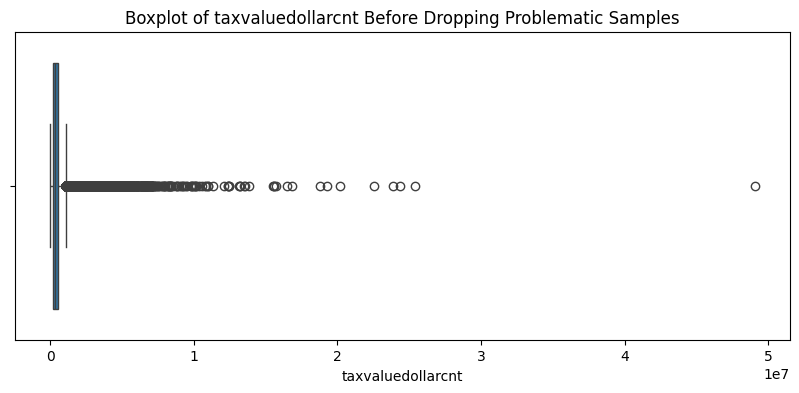

In [31]:
## visualize target

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_stage3[target_col])
plt.title("Boxplot of taxvaluedollarcnt Before Dropping Problematic Samples")
plt.show()

In [32]:
## drop problematic samples if:
# 1. the target is missing
# 2. the row has too many null values
# 3. the target is an extreme outlier based on the IQR rule

def drop_problematic_samples(input_df, target_col='taxvaluedollarcnt', row_missing_threshold=40):
    df_stage3b = input_df.copy()
    
    # drop rows with missing target
    df_stage4 = df_stage3b.dropna(subset=[target_col]).copy()
    
    # keep counts for discussion
    dropped_target_null = len(df_stage3b) - len(df_stage4)
    
    # drop rows with too much missing data
    row_missing_pct = df_stage4.isnull().mean(axis=1) * 100
    before_row_missing_drop = len(df_stage4)
    df_stage5 = df_stage4.loc[row_missing_pct <= row_missing_threshold].copy()
    dropped_too_many_nulls = before_row_missing_drop - len(df_stage5)
    
    # drop extreme outliers in the target using IQR
    q1 = df_stage5[target_col].quantile(0.25)
    q3 = df_stage5[target_col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    before_outlier_drop = len(df_stage5)
    df_stage6 = df_stage5[
        (df_stage5[target_col] >= lower_bound) &
        (df_stage5[target_col] <= upper_bound)
    ].copy()
    dropped_target_outliers = before_outlier_drop - len(df_stage6)
    
    drop_summary = {
        "dropped_null_target": dropped_target_null,
        "dropped_too_many_nulls": dropped_too_many_nulls,
        "dropped_target_outliers": dropped_target_outliers,
        "final_row_count": len(df_stage6),
        "target_lower_bound": lower_bound,
        "target_upper_bound": upper_bound
    }
    
    return df_stage6, drop_summary

In [33]:
## clean the dataset with problematic rows removed

df_stage4, sample_drop_summary = drop_problematic_samples(
    df_stage3,
    target_col='taxvaluedollarcnt',
    row_missing_threshold=40
)

print("Sample drop summary:")
for k, v in sample_drop_summary.items():
    print(f"{k}: {v}")

print("\nShape before dropping problematic samples:", df_stage3.shape)
print("Shape after dropping problematic samples:", df_stage4.shape)

Sample drop summary:
dropped_null_target: 35
dropped_too_many_nulls: 206
dropped_target_outliers: 5136
final_row_count: 72236
target_lower_bound: -335409.0
target_upper_bound: 1111015.0

Shape before dropping problematic samples: (77613, 29)
Shape after dropping problematic samples: (72236, 29)


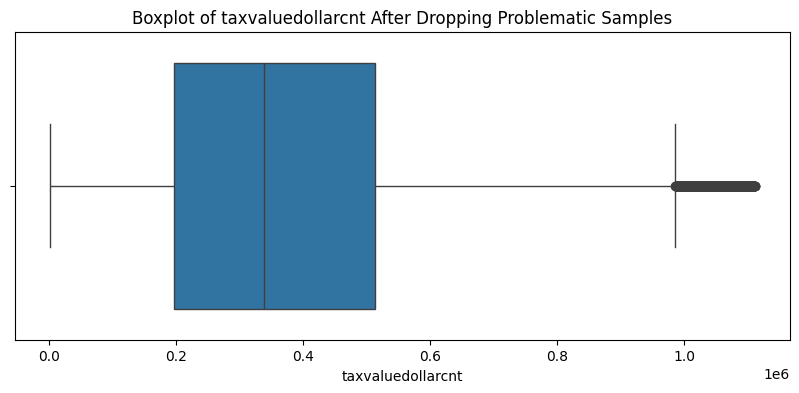

In [34]:
## visualize target now after row filtering

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_stage4['taxvaluedollarcnt'])
plt.title("Boxplot of taxvaluedollarcnt After Dropping Problematic Samples")
plt.show()

In [35]:
## check remaining missingness

remaining_row_missing_pct = df_stage4.isnull().mean(axis=1) * 100

print("Remaining row missingness summary:")
print(remaining_row_missing_pct.describe())

Remaining row missingness summary:
count    72236.000000
mean        17.199849
std          4.922752
min         10.344828
25%         13.793103
50%         17.241379
75%         20.689655
max         37.931034
dtype: float64


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


I removed problematic samples for three reasons. First, I dropped rows where the target variable taxvaluedollarcnt was missing because supervised regression requires a known target value for training. Second, I dropped rows with more than 40% missing values, since these rows contain too little information to support reliable modeling. I chose 40% because it takes out severly incomplete records while preserving rows that may still be recoverable through later analysis. Third, I removed extreme outliers in the target using the 1.5 * IQR rule. This is important for regression because unusually large property values can disproportionately influence the fitted model and reduce performance on typical homes.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [36]:
## check misisng values before imputation

print("Missing values before imputation: ")
print(df_stage4.isnull().sum().sort_values(ascending=False))

Missing values before imputation: 
numberofstories                 55489
airconditioningtypeid           49071
garagecarcnt                    48471
garagetotalsqft                 48471
regionidneighborhood            43701
heatingorsystemtypeid           25887
buildingqualitytypeid           25600
propertyzoningdesc              25140
unitcnt                         24884
lotsizesquarefeet                7944
finishedsquarefeet12             3226
regionidcity                     1367
fullbathcnt                       373
calculatedbathnbr                 373
censustractandblock               189
yearbuilt                          81
regionidzip                        33
calculatedfinishedsquarefeet       10
fips                                0
bedroomcnt                          0
bathroomcnt                         0
latitude                            0
regionidcounty                      0
propertycountylandusecode           0
propertylandusetypeid               0
longitude      

In [37]:
## impute missing values

def impute_missing_values(input_df):
    df_stage5 = input_df.copy()

    numeric_cols = df_stage5.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df_stage5.select_dtypes(include=['object', 'string']).columns

    # median imputation for numeric
    for col in numeric_cols:
        median_val = df_stage5[col].median()
        df_stage5[col] = df_stage5[col].fillna(median_val)

    # mode imputation for categorical
    for col in categorical_cols:
        mode_val = df_stage5[col].mode(dropna=True)
        if len(mode_val) > 0:
            df_stage5[col] = df_stage5[col].fillna(mode_val[0])

    zero_fill_cols = [
        'garagecarcnt',
        'garagetotalsqft',
        'poolcnt',
        'fireplacecnt'
    ]

    for col in zero_fill_cols:
        if col in df_stage5.columns:
            df_stage5[col] = df_stage5[col].fillna(0)

    return df_stage5

In [38]:
## apply the imputation

df_stage5 = impute_missing_values(df_stage4)

print("Shape after imputation: ", df_stage5.shape)

Shape after imputation:  (72236, 29)


In [39]:
## verify no more missing values

remaining_nulls = df_stage5.isnull().sum().sum()

print("Total remaining null values: ", remaining_nulls)

Total remaining null values:  0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


I applied different imputation strategies to handle the remaining missing values based on feature type. For numeric features, I used median imputation because it is good for outliers, which are common in this dataset in features like property values and square footage. For categorical features, I used mode imputation to preserve the most common category in each feature. Then for certain count based features like garage size, pool count, and fireplace count, I filled the missing values with zero. This combination of strategies makes sure that all missing values are handled while keeping the structure of the data.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [40]:
categorical_cols = df_stage5.select_dtypes(include=['object', 'string']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))

Categorical columns:
['propertycountylandusecode', 'propertyzoningdesc']

Number of categorical columns: 2


In [41]:
def encode_categorical_features(input_df):
    df_stage6_input = input_df.copy()
    
    categorical_cols = df_stage6_input.select_dtypes(include=['object', 'string']).columns.tolist()
    
    df_stage6 = pd.get_dummies(
        df_stage6_input,
        columns=categorical_cols,
        drop_first=True
    )
    
    return df_stage6, categorical_cols

In [42]:
df_stage6, encoded_columns = encode_categorical_features(df_stage5)

print("Encoded categorical columns:")
print(encoded_columns)

print("\nShape before encoding:", df_stage5.shape)
print("Shape after encoding:", df_stage6.shape)

Encoded categorical columns:
['propertycountylandusecode', 'propertyzoningdesc']

Shape before encoding: (72236, 29)
Shape after encoding: (72236, 1923)


In [43]:
## verify now there are no categorical columns

remaining_categorical = df_stage6.select_dtypes(include=['object', 'string']).columns.tolist()

print("Remaining categorical columns:", remaining_categorical)

Remaining categorical columns: []


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [44]:
## correlation matrix
# this hsows pairwise relationships between numeric features
# at first, I did it for all, and the kernel kept crashing, so now it is for a smaller set

target_col = 'taxvaluedollarcnt'

df_corr_input = df_stage6.select_dtypes(include=np.number).copy()

target_corr_abs = df_corr_input.corr()[target_col].abs().sort_values(ascending=False)
top_corr_features = target_corr_abs.head(21).index.tolist()   # includes target

df_small = df_corr_input[top_corr_features].copy()

print("Features in reduced analysis set:")
print(df_small.columns.tolist())
print("\nReduced shape:", df_small.shape)

Features in reduced analysis set:
['taxvaluedollarcnt', 'finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bathroomcnt', 'fullbathcnt', 'bedroomcnt', 'yearbuilt', 'buildingqualitytypeid', 'latitude', 'heatingorsystemtypeid', 'regionidcounty', 'garagetotalsqft', 'garagecarcnt', 'numberofstories', 'fips', 'rawcensustractandblock', 'roomcnt', 'regionidneighborhood', 'airconditioningtypeid', 'lotsizesquarefeet']

Reduced shape: (72236, 21)


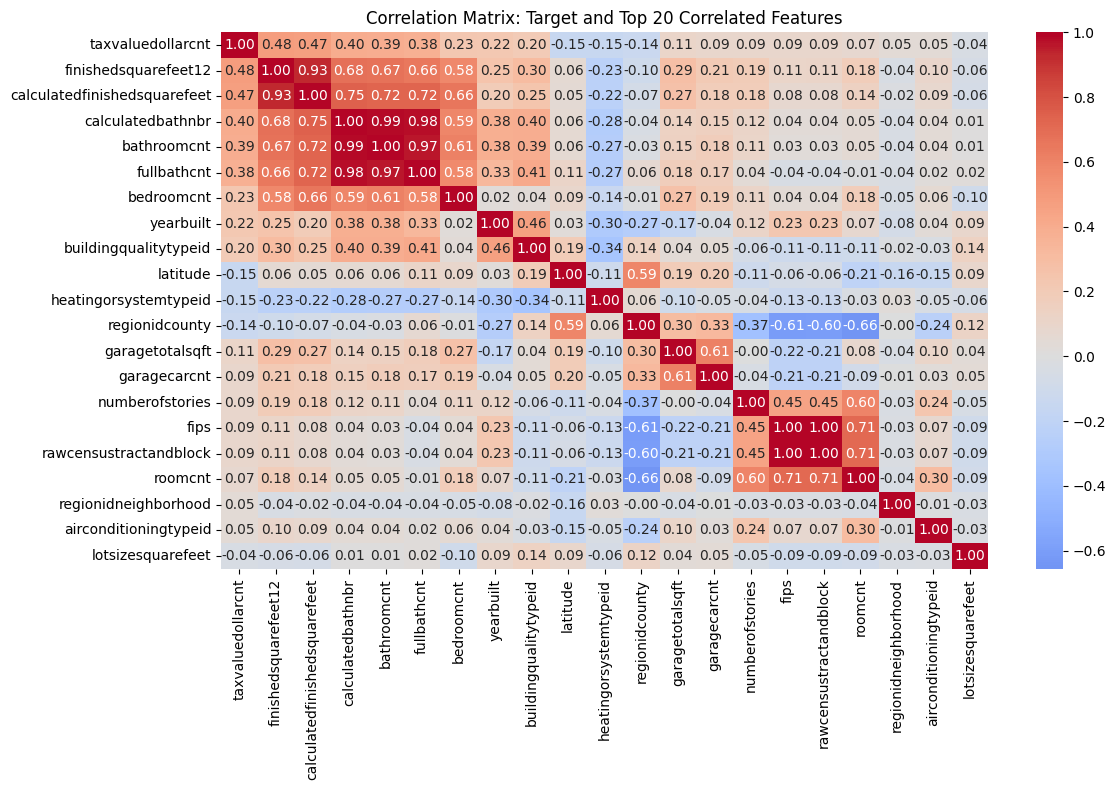

In [45]:
## correlation matrix for reduced feature set
# shows pairwise correlations for target and most relevant features

corr_matrix_small = df_small.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_small, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix: Target and Top 20 Correlated Features")
plt.tight_layout()
plt.show()

In [46]:
## correlation of each feature with the target

target_corr_small = corr_matrix_small[target_col].sort_values(ascending=False)

print("Top positively correlated features:")
print(target_corr_small.head(10))

print("\nTop negatively correlated features:")
print(target_corr_small.tail(10))

Top positively correlated features:
taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.480031
calculatedfinishedsquarefeet    0.474181
calculatedbathnbr               0.403257
bathroomcnt                     0.394272
fullbathcnt                     0.375378
bedroomcnt                      0.227531
yearbuilt                       0.221054
buildingqualitytypeid           0.202311
garagetotalsqft                 0.106097
Name: taxvaluedollarcnt, dtype: float64

Top negatively correlated features:
numberofstories           0.091815
fips                      0.090909
rawcensustractandblock    0.089578
roomcnt                   0.070169
regionidneighborhood      0.048028
airconditioningtypeid     0.046700
lotsizesquarefeet        -0.043703
regionidcounty           -0.136257
heatingorsystemtypeid    -0.145592
latitude                 -0.153268
Name: taxvaluedollarcnt, dtype: float64


In [47]:
## compute f-statistcs for reduced feature set
# f-statistics show the strength of the linear relationship between each feature

from sklearn.feature_selection import f_regression

X_small = df_small.drop(columns=[target_col])
y = df_small[target_col]

f_scores, p_values = f_regression(X_small, y)

f_df_small = pd.DataFrame({
    "feature": X_small.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values(by="f_score", ascending=False)

print("Top features by F-statistic:")
print(f_df_small.head(15))

Top features by F-statistic:
                         feature       f_score        p_value
0           finishedsquarefeet12  21628.822516   0.000000e+00
1   calculatedfinishedsquarefeet  20952.866400   0.000000e+00
2              calculatedbathnbr  14027.527931   0.000000e+00
3                    bathroomcnt  13295.627389   0.000000e+00
4                    fullbathcnt  11847.870847   0.000000e+00
5                     bedroomcnt   3943.740768   0.000000e+00
6                      yearbuilt   3711.055014   0.000000e+00
7          buildingqualitytypeid   3082.703484   0.000000e+00
8                       latitude   1737.684581   0.000000e+00
9          heatingorsystemtypeid   1564.305517   0.000000e+00
10                regionidcounty   1366.473793  2.418831e-296
11               garagetotalsqft    822.368848  7.587187e-180
12                  garagecarcnt    615.301205  2.906857e-135
13               numberofstories    614.114708  5.239724e-135
14                          fips    601.9

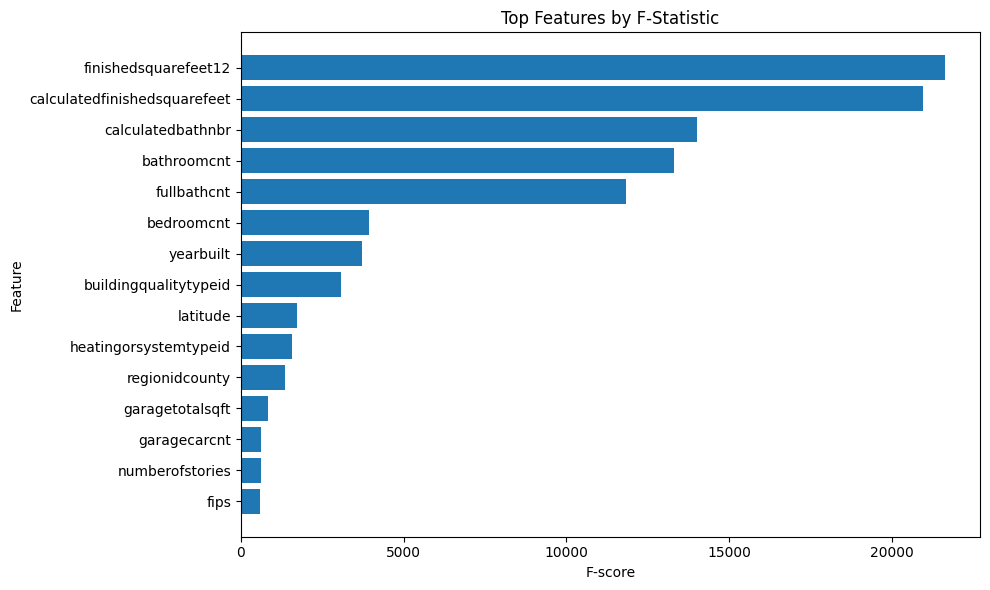

In [48]:
## bar chart of f-statistics

top_n = 15
top_f_df = f_df_small.head(top_n).sort_values("f_score")

plt.figure(figsize=(10, 6))
plt.barh(top_f_df["feature"], top_f_df["f_score"])
plt.title("Top Features by F-Statistic")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
## identify highly correlated feature pairs

threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix_small.columns)):
    for j in range(i):
        corr_val = corr_matrix_small.iloc[i, j]
        if abs(corr_val) > threshold:
            col1 = corr_matrix_small.columns[i]
            col2 = corr_matrix_small.columns[j]
            high_corr_pairs.append((col1, col2, corr_val))

print("Highly correlated feature pairs (absolute correlation > 0.85):")
for pair in high_corr_pairs:
    print(pair)

Highly correlated feature pairs (absolute correlation > 0.85):
('calculatedfinishedsquarefeet', 'finishedsquarefeet12', np.float64(0.9310654216363815))
('bathroomcnt', 'calculatedbathnbr', np.float64(0.9862679216366821))
('fullbathcnt', 'calculatedbathnbr', np.float64(0.9804601425929983))
('fullbathcnt', 'bathroomcnt', np.float64(0.9662083682260951))
('rawcensustractandblock', 'fips', np.float64(0.9999368901614176))


: 

In [ ]:
## forward feature selection on the reduced feature set

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction='forward',
    scoring='r2',
    cv=5,
    n_jobs=-1
)

forward_selector.fit(X_small, y)

forward_features = X_small.columns[forward_selector.get_support()].tolist()

print("Forward-selected features:")
print(forward_features)

In [ ]:
## backward feature selection on the reduced feature set

backward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction='backward',
    scoring='r2',
    cv=5,
    n_jobs=-1
)

backward_selector.fit(X_small, y)

backward_features = X_small.columns[backward_selector.get_support()].tolist()

print("Backward-selected features:")
print(backward_features)

Backward-selected features:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt', 'yearbuilt', 'latitude', 'garagetotalsqft', 'fips', 'rawcensustractandblock', 'roomcnt']


In [ ]:
## compare foward and backward selection

selection_summary = pd.DataFrame({
    "feature": X_small.columns
})

selection_summary["forward_selected"] = selection_summary["feature"].isin(forward_features)
selection_summary["backward_selected"] = selection_summary["feature"].isin(backward_features)

print(selection_summary.sort_values(
    by=["forward_selected", "backward_selected", "feature"],
    ascending=[False, False, True]
))

                         feature  forward_selected  backward_selected
5                     bedroomcnt              True               True
1   calculatedfinishedsquarefeet              True               True
0           finishedsquarefeet12              True               True
14                          fips              True               True
8                       latitude              True               True
15        rawcensustractandblock              True               True
6                      yearbuilt              True               True
2              calculatedbathnbr              True              False
10                regionidcounty              True              False
17          regionidneighborhood              True              False
3                    bathroomcnt             False               True
11               garagetotalsqft             False               True
16                       roomcnt             False               True
18         aircondit

In [ ]:
## summarize the results

relationship_summary = pd.DataFrame({
    "feature": X_small.columns,
    "correlation_with_target": [corr_matrix_small.loc[col, target_col] for col in X_small.columns]
}).merge(
    f_df_small,
    on="feature",
    how="left"
).sort_values(by="f_score", ascending=False)

print(relationship_summary)

                         feature  correlation_with_target       f_score  \
0           finishedsquarefeet12                 0.480031  21628.822516   
1   calculatedfinishedsquarefeet                 0.474181  20952.866400   
2              calculatedbathnbr                 0.403257  14027.527931   
3                    bathroomcnt                 0.394272  13295.627389   
4                    fullbathcnt                 0.375378  11847.870847   
5                     bedroomcnt                 0.227531   3943.740768   
6                      yearbuilt                 0.221054   3711.055014   
7          buildingqualitytypeid                 0.202311   3082.703484   
8                       latitude                -0.153268   1737.684581   
9          heatingorsystemtypeid                -0.145592   1564.305517   
10                regionidcounty                -0.136257   1366.473793   
11               garagetotalsqft                 0.106097    822.368848   
12                  garag

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The analysis shows that property size and structure features, especially square footage and bathroom related variables have the strongest relationships with the target. These ffeatures are highly correlated with each other, indicating multicollinearlity and redundancy. The correlation matrix and f-statistics agree on the most important predictors, and forward/backward selection methods largely select similar features, though they differ slightly due to overlapping information. Overall, the methods are consistent in indentifying key drivers of property value while highlighting potential issues with correlated features.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

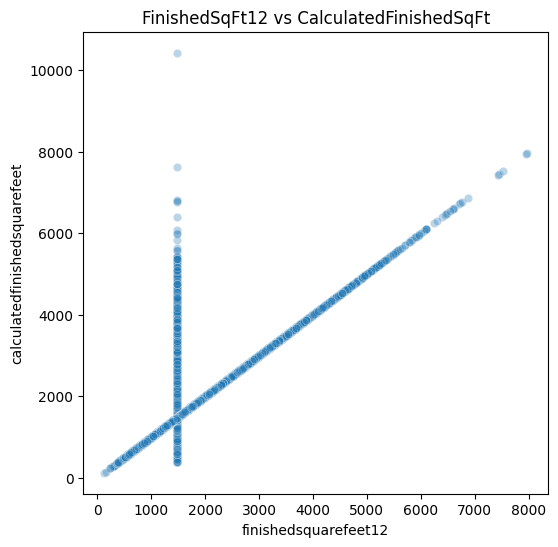

In [ ]:
# 1. finishedsquarefeet12 vs calculatedfinishedsquarefeet

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df_stage6['finishedsquarefeet12'],
    y=df_stage6['calculatedfinishedsquarefeet'],
    alpha=0.3
)

plt.title("FinishedSqFt12 vs CalculatedFinishedSqFt")
plt.xlabel("finishedsquarefeet12")
plt.ylabel("calculatedfinishedsquarefeet")
plt.show()

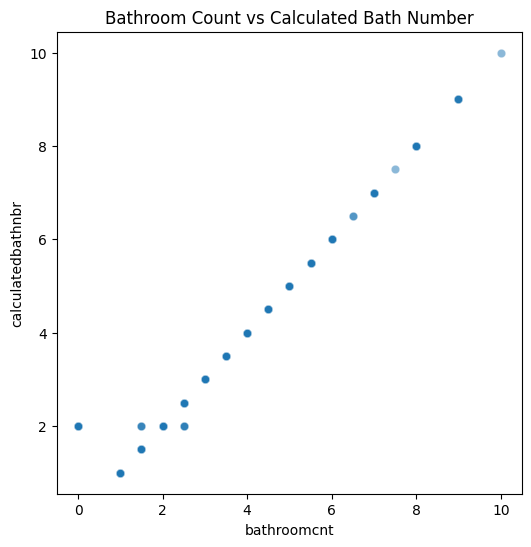

In [ ]:
# 2. bathroomcnt vs calculatedbathnbr

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df_stage6['bathroomcnt'],
    y=df_stage6['calculatedbathnbr'],
    alpha=0.3
)

plt.title("Bathroom Count vs Calculated Bath Number")
plt.xlabel("bathroomcnt")
plt.ylabel("calculatedbathnbr")
plt.show()

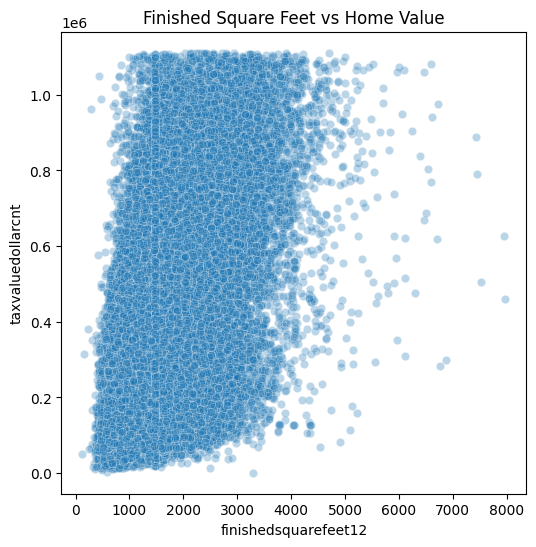

In [ ]:
# 3. finishedsquarefeet12 vs taxvaluedollarcnt

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df_stage6['finishedsquarefeet12'],
    y=df_stage6['taxvaluedollarcnt'],
    alpha=0.3
)

plt.title("Finished Square Feet vs Home Value")
plt.xlabel("finishedsquarefeet12")
plt.ylabel("taxvaluedollarcnt")
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The first two features show a very strong linear relationship. However, the plot shows a noticeable vertical cluster around 1500 square feet where calculatedfinishedsquarefeet varies widely while finishedsquarefeet12 stays constant. This suggests that while the features are highly correlated overall, they are not perfectly interchangeable and may capture slightly different aspects of property size. There are also a few outliers with unusally large values.

The second relationship is almost perfectly linera, confirming that these variables represent nearly the same information. Unlike the square footage pair, there is very little deviation from the line, indicating minimal differences between the two features. There is redundancy with almost no added value from including both.

In the third relationship, there is a general positive relationship between square footage and home value, the plot shows a very large spread in values, especially for homes between 1000-4000 square feet. This indicates that square footage alone does not strongly determine price, and other factors such as location, quality, and amentities likely play a significant role. The vertical clustering could mean that many homes with similar sizes can have very different values, weakening the predictive strength compared to what the correlation alone may suggest.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [ ]:
# 1. log transformation
# 2. feature scaling (standardization)
# 3. polynomial features

target_col = 'taxvaluedollarcnt'

X_base_small = df_small.drop(columns=[target_col]).copy()
y_small = df_small[target_col].copy()

print("Shape of X:", X_base_small.shape)
print("Features used:")
print(X_base_small.columns.tolist())

NameError: name 'df_small' is not defined

In [ ]:
## log transformation

X_base_small = df_small.drop(columns=[target_col]).copy()
y_small = df_small[target_col].copy()

print("Transformation input shape:", X_base_small.shape)
print("Features being tested:")
print(X_base_small.columns.tolist())

NameError: name 'df_small' is not defined

In [ ]:
## apply log transformation

X_log = log_transform_features(X_base)

from sklearn.feature_selection import f_regression

# Start from the smaller analysis set
X_small_base = df_small.drop(columns=[target_col]).copy()
y_small = df_small[target_col].copy()

# Apply log transform only to positive-valued features
X_log_small = log_transform_features(X_small_base)

f_scores_log, p_values_log = f_regression(X_log_small, y_small)

f_log_df = pd.DataFrame({
    "feature": X_log_small.columns,
    "f_score": f_scores_log,
    "p_value": p_values_log
}).sort_values(by="f_score", ascending=False)

print("Top features after log transform:")
print(f_log_df.head(15))

NameError: name 'X_base' is not defined

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

